In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
df = pd.read_csv("corporate_dataset.csv")
df.head()

,company_id,industry,country,year,ai_adoption_level,ai_investment_usd,automation_rate,cost_savings,revenue_impact,productivity_gain,employee_ai_training_hours,ai_maturity_score,deployment_count
0,CORP-06613,Financial Services,China,2029,0.4987,11747237,0.4119,3519354,2751513,0.3924,76.8,6.37,29
1,CORP-01597,Agriculture,Germany,2032,0.5213,1267219,0.4580,295244,304776,0.4639,83.2,7.19,37
2,CORP-02938,Energy,United States,2024,0.6147,8168951,0.5821,2472329,5170304,0.4953,123.1,6.72,26
3,CORP-05207,Retail,Germany,2021,0.4401,1234261,0.2880,512061,-233448,0.3078,63.1,5.68,21
4,CORP-07489,Technology,United States,2024,0.1918,5000645,0.1906,2122064,2110644,0.1910,29.6,4.33,16


In [5]:
# to add additional features and rows
df["roi_score"] = (
    (df["revenue_impact"] + df["cost_savings"] - df["ai_investment_usd"])
    / df["ai_investment_usd"]
)

df["investment_efficiency"] = (
    df["revenue_impact"] / df["ai_investment_usd"]
)
df["productivity_index"] = (
    df["productivity_gain"] * df["automation_rate"]
)
df["ai_effectiveness_score"] = (
    df["ai_maturity_score"]
    * df["ai_adoption_level"]
    * df["automation_rate"]
)
df["revenue_per_ai_dollar"] = (
    df["revenue_impact"]
    / df["ai_investment_usd"]
)
df["business_impact_score"] = (
    df["revenue_impact"]
    + df["cost_savings"]
)
df.head()

,company_id,industry,country,year,ai_adoption_level,ai_investment_usd,automation_rate,cost_savings,revenue_impact,productivity_gain,employee_ai_training_hours,ai_maturity_score,deployment_count,roi_score,investment_efficiency,productivity_index,ai_effectiveness_score,revenue_per_ai_dollar,business_impact_score
0,CORP-06613,Financial Services,China,2029,0.4987,11747237,0.4119,3519354,2751513,0.3924,76.8,6.37,29,-0.466184,0.234226,0.161630,1.308491,0.234226,6270867
1,CORP-01597,Agriculture,Germany,2032,0.5213,1267219,0.4580,295244,304776,0.4639,83.2,7.19,37,-0.526506,0.240508,0.212466,1.716651,0.240508,600020
2,CORP-02938,Energy,United States,2024,0.6147,8168951,0.5821,2472329,5170304,0.4953,123.1,6.72,26,-0.064429,0.632921,0.288314,2.404529,0.632921,7642633
3,CORP-05207,Retail,Germany,2021,0.4401,1234261,0.2880,512061,-233448,0.3078,63.1,5.68,21,-0.774267,-0.189140,0.088646,0.719933,-0.189140,278613
4,CORP-07489,Technology,United States,2024,0.1918,5000645,0.1906,2122064,2110644,0.1910,29.6,4.33,16,-0.153568,0.422074,0.036405,0.158292,0.422074,4232708


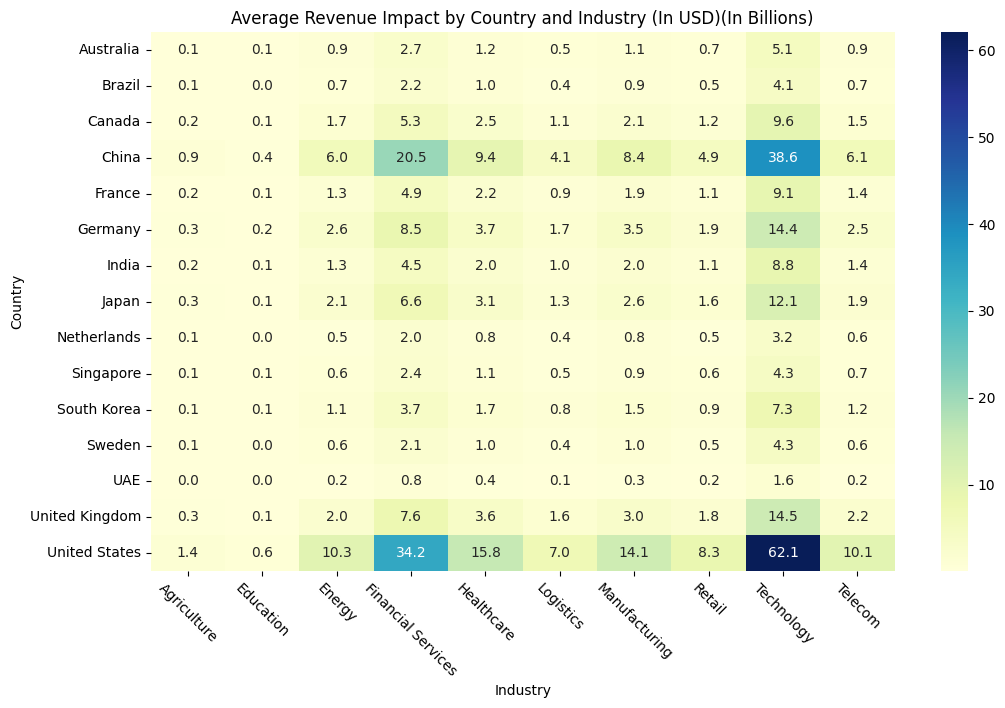

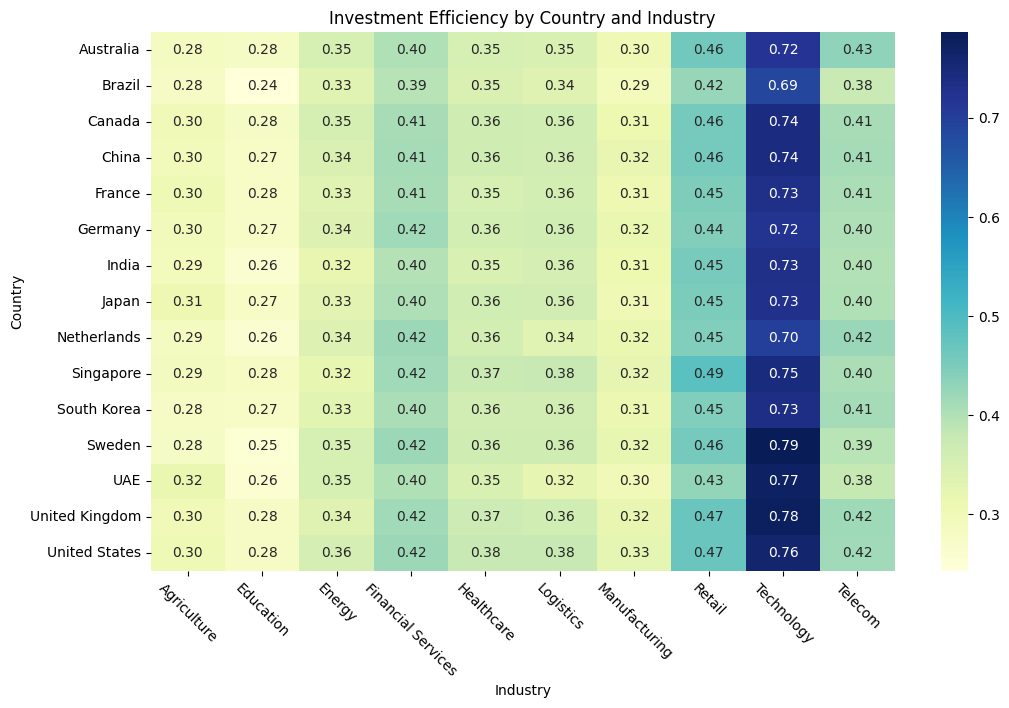

In [18]:
#Visualizations
#Scatter Plot
#X-Axis: AI Investment

#Y-Axis: Revenue Increase

#Used to analyze the relationship between investment and business outcomes.

#Top 10 Industries by Revenue Impact
#Compare industries benefiting the most from AI implementation.

#Country Revenue Heatmap
#Visual representation of revenue growth across countries.

heatmap_data = df.pivot_table(
    values="revenue_impact",
    index="country",
    columns="industry",
    aggfunc="sum"
)

heatmap_data = heatmap_data / 1e9
plt.figure(figsize=(12,7))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)
plt.xticks(rotation=-45)
plt.xlabel('Industry')
plt.ylabel('Country')
plt.title("Average Revenue Impact by Country and Industry (In USD)(In Billions)")
plt.show()

#ROI Analysis Dashboard
#Measure investment effectiveness across industries and regions.

efficiency_heatmap = df.pivot_table(
    values="investment_efficiency",
    index="country",
    columns="industry",
    aggfunc="mean"
)
plt.figure(figsize=(12,7))
sns.heatmap(
    efficiency_heatmap,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)
plt.xlabel('Industry')
plt.ylabel('Country')
plt.xticks(rotation=-45)
plt.title("Investment Efficiency by Country and Industry")
plt.show()

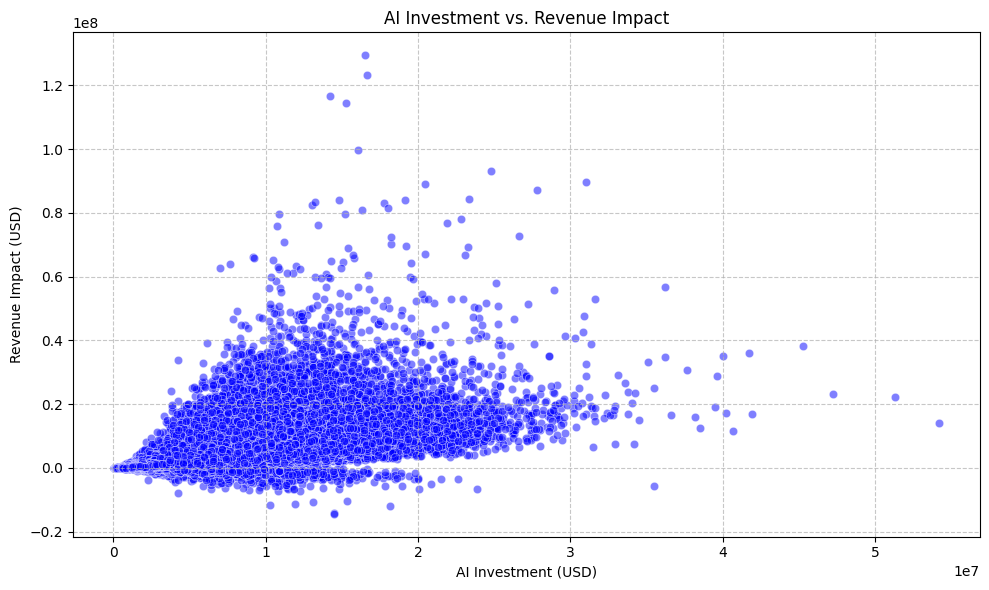

C:\Users\venum\AppData\Local\Temp\ipykernel_22044\1480463643.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


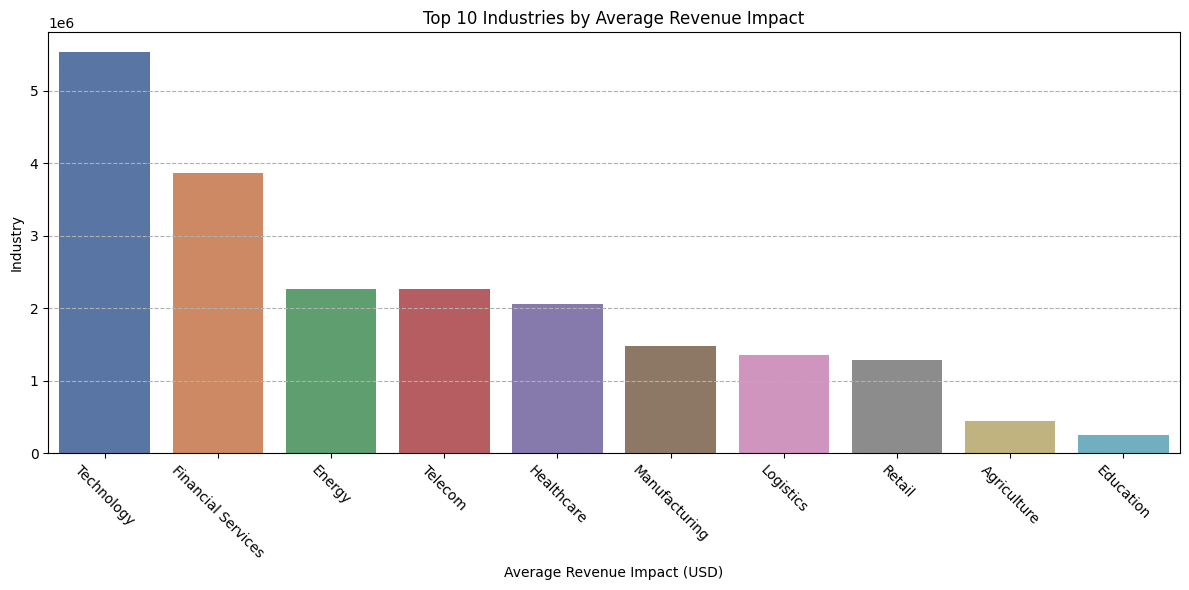

In [7]:
# --- Plot 1: Scatter Plot ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='ai_investment_usd', 
    y='revenue_impact', 
    alpha=0.5, 
    color='blue'
)
plt.title('AI Investment vs. Revenue Impact')
plt.xlabel('AI Investment (USD)')
plt.ylabel('Revenue Impact (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ---Plot 2: Top 10 Industries by Revenue Impact---
top_industries = df.groupby('industry')['revenue_impact'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
# Fixed: Removed the incompatible 'legend=False' keyword argument
sns.barplot(
    y=top_industries.values, 
    x=top_industries.index, 
    palette='deep'
)
plt.grid(axis='y', linestyle='--')
plt.title('Top 10 Industries by Average Revenue Impact')
plt.xlabel('Average Revenue Impact (USD)')
plt.ylabel('Industry')
plt.xticks(rotation=-45)
plt.tight_layout()
plt.show()